/usr/bin/python3: No module named ensurepip
                       Grupo  corr(CA, ŷ)  corr(TB, ŷ)  corr(I, ŷ)  σ(I)/σ(C)  corr(S, I) R2 ✓ R3 ✓ R4 ✓ R5 ✓ R6 ✓
País                                                                                                              
Estados Unidos  Desarrollado       -0.232       -0.212       0.530      0.796       0.687   Sí   Sí   Sí   No   Sí
Alemania        Desarrollado       -0.022       -0.008       0.270      1.637      -0.265   Sí   Sí   Sí   Sí   No
China              Emergente        0.082        0.104       0.123      0.916       0.838   No   No   Sí   No   Sí
Perú               Emergente       -0.249       -0.058       0.444      0.665       0.564   Sí   Sí   Sí   No   Sí
Chile              Emergente       -0.306       -0.271       0.501      0.707       0.124   Sí   Sí   Sí   No   Sí
Corea del Sur      Emergente       -0.627       -0.642       0.396      1.773       0.612   Sí   Sí   Sí   Sí   Sí
Turquía            Emergente       -

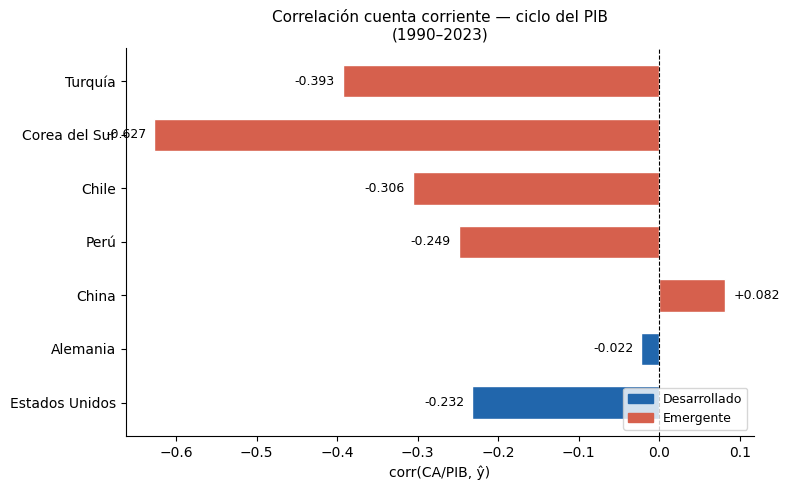

In [5]:
# ============================================================
# BLOQUE A — Ítem 22
# ============================================================


import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install wbgapi
!{sys.executable} -m pip install statsmodels

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# Configuración

indicators = {
    'NY.GDP.MKTP.KD': 'gdp_real',
    'BN.CAB.XOKA.GD.ZS': 'ca_gdp',
    'NE.RSB.GNFS.ZS': 'tb_gdp',
    'NE.GDI.TOTL.ZS': 'inv_gdp',
    'NY.GNS.ICTR.ZS': 'sav_gdp',
    'NE.CON.TOTL.ZS': 'cons_gdp',
}

countries = {
    'USA': 'Estados Unidos',
    'DEU': 'Alemania',
    'CHN': 'China',
    'PER': 'Perú',
    'CHL': 'Chile',
    'KOR': 'Corea del Sur',
    'TUR': 'Turquía',
}

grupos = {
    'USA': 'Desarrollado',
    'DEU': 'Desarrollado',
    'CHN': 'Emergente',
    'PER': 'Emergente',
    'CHL': 'Emergente',
    'KOR': 'Emergente',
    'TUR': 'Emergente',
}

# Función para procesar un país

def procesar_pais(codigo):
    raw = wb.data.DataFrame(
        list(indicators.keys()),
        economy=codigo,
        time=range(1990, 2024)
    )
    df = raw.T
    df.columns = [indicators[c] for c in raw.index]
    df.index = [int(str(i).replace('YR', '')) for i in df.index]
    df = df.sort_index().astype(float)

    # Filtro HP
    df_clean = df['gdp_real'].dropna()
    cycle, _ = hpfilter(x=np.log(df_clean), lamb=6.25)
    df['gdp_cycle'] = cycle.reindex(df.index)

    # Estadísticos
    corr_CA  = df['gdp_cycle'].corr(df['ca_gdp'])
    corr_TB  = df['gdp_cycle'].corr(df['tb_gdp'])
    corr_I   = df['gdp_cycle'].corr(df['inv_gdp'])
    vol_ratio = df['inv_gdp'].std() / df['cons_gdp'].std()
    corr_SI  = df['sav_gdp'].corr(df['inv_gdp'])

    return {
        'País': countries[codigo],
        'Grupo': grupos[codigo],
        'corr(CA, ŷ)': round(corr_CA, 3),
        'corr(TB, ŷ)': round(corr_TB, 3),
        'corr(I, ŷ)':  round(corr_I,  3),
        'σ(I)/σ(C)':   round(vol_ratio, 3),
        'corr(S, I)':  round(corr_SI,  3),
    }

# Tabla maestra

resultados = [procesar_pais(c) for c in countries]
tabla = pd.DataFrame(resultados).set_index('País')

# Columnas de verificación
tabla['R2 ✓'] = tabla['corr(CA, ŷ)'].apply(lambda x: 'Sí' if x < 0 else 'No')
tabla['R3 ✓'] = tabla['corr(TB, ŷ)'].apply(lambda x: 'Sí' if x < 0 else 'No')
tabla['R4 ✓'] = tabla['corr(I, ŷ)'].apply(lambda x: 'Sí' if x > 0 else 'No')
tabla['R5 ✓'] = tabla['σ(I)/σ(C)'].apply(lambda x: 'Sí' if x > 1 else 'No')
tabla['R6 ✓'] = tabla['corr(S, I)'].apply(lambda x: 'Sí' if x > 0 else 'No')

print(tabla.to_string())

# Gráfico de barras horizontales — corr(CA/PIB, ŷ)

fig, ax = plt.subplots(figsize=(8, 5))

colores = {'Desarrollado': '#2166ac', 'Emergente': '#d6604d'}

paises  = tabla.index.tolist()
valores = tabla['corr(CA, ŷ)'].tolist()
grupos_lista = tabla['Grupo'].tolist()
colors  = [colores[g] for g in grupos_lista]

bars = ax.barh(paises, valores, color=colors, edgecolor='white', height=0.6)

# Línea en cero
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Etiquetas de valor
for bar, val in zip(bars, valores):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color='#2166ac', label='Desarrollado'),
           Patch(color='#d6604d', label='Emergente')]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

ax.set_xlabel('corr(CA/PIB, ŷ)', fontsize=10)
ax.set_title('Correlación cuenta corriente — ciclo del PIB\n(1990–2023)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barras_CA_ciclo.png', dpi=150)
plt.show()

Corr(CA/Y, ciclo) con inversión: -0.033
Corr(CA/Y, ciclo) dotación: 0.318


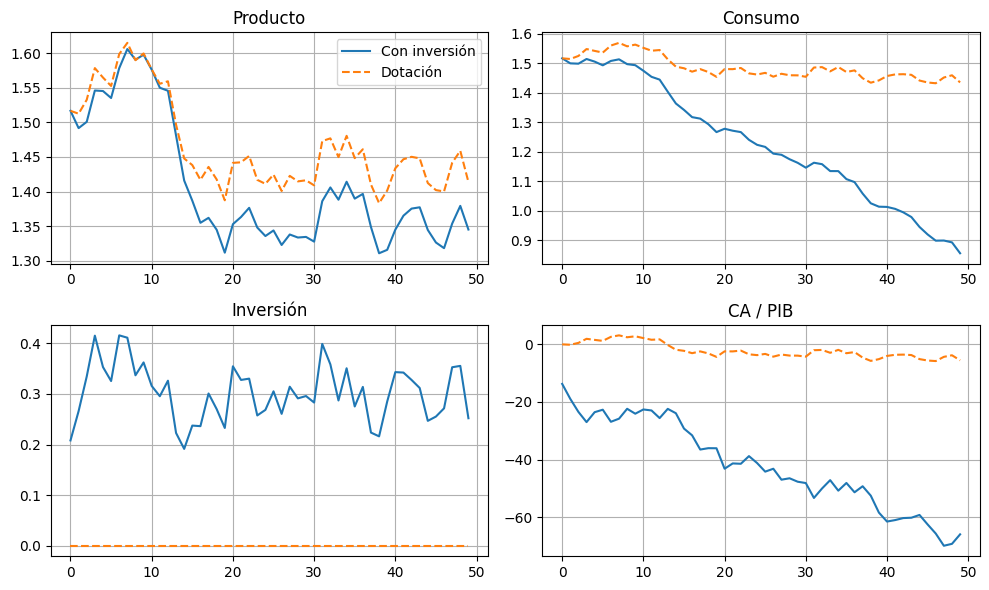

In [6]:
# ============================================================
# BLOQUE B — Ítem 24
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# FUNCIÓN

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                    rho=0.90, sigma_eps=0.02, T=50, seed=42,
                    con_inversion=True):

    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)

    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]

    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha
    c_ss = y_ss - delta * k_ss

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T); b = np.zeros(T+1)

    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1-delta) * k[t]
            i[t] = k[t+1] - (1-delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0

        c[t] = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)
        b[t+1] = (1+r_star)*b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]

    return pd.DataFrame({
        'Y': y, 'C': c, 'I': i, 'CA_Y': CA/y * 100
    })

# SIMULACIONES

df_inv = simular_economia(con_inversion=True)
df_dot = simular_economia(con_inversion=False)

# CICLO DEL PIB

cycle_inv, _ = hpfilter(np.log(df_inv['Y']), lamb=6.25)
cycle_dot, _ = hpfilter(np.log(df_dot['Y']), lamb=6.25)

# correlaciones
corr_inv = np.corrcoef(df_inv['CA_Y'], cycle_inv)[0,1]
corr_dot = np.corrcoef(df_dot['CA_Y'], cycle_dot)[0,1]

print("Corr(CA/Y, ciclo) con inversión:", round(corr_inv,3))
print("Corr(CA/Y, ciclo) dotación:", round(corr_dot,3))

# GRÁFICO 2x2

fig, axs = plt.subplots(2,2, figsize=(10,6))

# Producto
axs[0,0].plot(df_inv['Y'], label='Con inversión')
axs[0,0].plot(df_dot['Y'], linestyle='--', label='Dotación')
axs[0,0].set_title("Producto")

# Consumo
axs[0,1].plot(df_inv['C'])
axs[0,1].plot(df_dot['C'], linestyle='--')
axs[0,1].set_title("Consumo")

# Inversión
axs[1,0].plot(df_inv['I'])
axs[1,0].plot(df_dot['I'], linestyle='--')
axs[1,0].set_title("Inversión")

# Cuenta corriente / PIB
axs[1,1].plot(df_inv['CA_Y'])
axs[1,1].plot(df_dot['CA_Y'], linestyle='--')
axs[1,1].set_title("CA / PIB")

for ax in axs.flat:
    ax.grid()

axs[0,0].legend()

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# BLOQUE B — Ítem 25
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter

# FUNCIÓN ORIGINAL

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                    rho=0.90, sigma_eps=0.02, T=100, seed=42,
                    con_inversion=True):

    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)

    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]

    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T); b = np.zeros(T+1)

    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1-delta) * k[t]
            i[t] = k[t+1] - (1-delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0

        c[t] = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)
        b[t+1] = (1+r_star)*b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]

    return pd.DataFrame({
        'I': i,
        'CA': CA
    })

# FUNCIÓN PARA EVALUAR CAMBIOS

def evaluar_parametro(nombre, valores, base_params):
    resultados = []

    for v in valores:
        params = base_params.copy()
        params[nombre] = v

        df = simular_economia(**params)

        resultados.append({
            nombre: v,
            'I_prom': df['I'].mean(),
            'CA_prom': df['CA'].mean()
        })

    return pd.DataFrame(resultados)

# PARÁMETROS BASE

base = {
    'alpha': 0.33,
    'beta': 0.96,
    'delta': 0.10,
    'r_star': 0.04,
    'rho': 0.90,
    'sigma_eps': 0.02,
    'T': 100,
    'seed': 42,
    'con_inversion': True
}

# SIMULACIONES

rho_vals = [0.3, 0.7, 0.95]
alpha_vals = [0.15, 0.33, 0.50]
r_vals = [0.02, 0.04, 0.08]

print("\n--- Cambio en rho ---")
print(evaluar_parametro('rho', rho_vals, base))

print("\n--- Cambio en alpha ---")
print(evaluar_parametro('alpha', alpha_vals, base))

print("\n--- Cambio en r_star ---")
print(evaluar_parametro('r_star', r_vals, base))


--- Cambio en rho ---
    rho    I_prom   CA_prom
0  0.30  0.323252 -1.039925
1  0.70  0.321160 -1.045896
2  0.95  0.306362 -1.083408

--- Cambio en alpha ---
   alpha    I_prom   CA_prom
0   0.15  0.095540 -0.338673
1   0.33  0.314902 -1.063594
2   0.50  1.106850 -3.688867

--- Cambio en r_star ---
   r_star    I_prom   CA_prom
0    0.02  0.403843 -0.658449
1    0.04  0.314902 -1.063594
2    0.08  0.207367 -3.361158


In [8]:
# ============================================================
# BLOQUE B — Ítem 26
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter

# FUNCIÓN ORIGINAL

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                    rho=0.90, sigma_eps=0.02, T=100, seed=42,
                    con_inversion=True):

    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)

    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]

    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T); b = np.zeros(T+1)

    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha)

        k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
        k[t+1] = 0.5 * k_opt + 0.5 * (1-delta) * k[t]
        i[t] = k[t+1] - (1-delta) * k[t]

        c[t] = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)
        b[t+1] = (1+r_star)*b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]

    return pd.DataFrame({
        'Y': y,
        'I': i,
        'CA_Y': CA/y * 100
    })

# MOMENTOS

def momentos(df):
    cycle, _ = hpfilter(np.log(df['Y']), lamb=6.25)
    corr_CA = np.corrcoef(df['CA_Y'], cycle)[0,1]
    corr_I  = np.corrcoef(df['I'], cycle)[0,1]
    return round(corr_CA,3), round(corr_I,3)

# PARÁMETROS DEL PAPER (ANUALIZADOS)

china_paper = {
    'alpha': 0.32,           # a
    'beta': 0.973**4,        # anualizado
    'delta': 1-(1-0.025)**4, # anualizado
    'r_star': (1+0.0277)**4 - 1,  # anualizado
    'rho': 0.95,             # asumido alto (consistente con literatura)
    'sigma_eps': 0.02,
    'T': 100,
    'seed': 42,
    'con_inversion': True
}

# SIMULACIÓN

df = simular_economia(**china_paper)
corr_CA, corr_I = momentos(df)

print("=== CHINA (calibración paper) ===")
print("beta:", round(china_paper['beta'],3))
print("delta:", round(china_paper['delta'],3))
print("r_star:", round(china_paper['r_star'],3))
print("corr(CA/Y, ciclo):", corr_CA)
print("corr(I, ciclo):", corr_I)

=== CHINA (calibración paper) ===
beta: 0.896
delta: 0.096
r_star: 0.115
corr(CA/Y, ciclo): 0.01
corr(I, ciclo): 0.565
